In [5]:
%pip install -q earthengine-api geemap

import ee
ee.Authenticate()

ee.Initialize(project="riverprojectnaira")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [6]:
# =============================================================================
# 1️⃣ PARAMETERS CELL — No computation, only imports and constants
# =============================================================================
import os
import glob
import warnings

# Suppress pyresample ImageContainer deprecation warning (logic unchanged)
warnings.filterwarnings("ignore", category=FutureWarning, module="pyresample")

import numpy as np
import h5py
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from rasterio.merge import merge
from pyproj import CRS, Transformer

try:
    from pyresample import geometry, image
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyresample"])
    from pyresample import geometry, image

try:
    import ee
except ImportError:
    ee = None

# Constant paths
HDF5_PATH = "C:/Users/daksh/Desktop/Research/RIVERPROJECT/Source/GITCO-SVI01-SVI02-SVI03-SVI04-SVI05_npp_d20260125_t2315015_e2320401_b73826_c20260127210812288114_oeac_ops.h5"

EE_EXPORT_FOLDER = "EarthEngineExports"
JRC_EXPORT_DIR = os.path.join("C:/Users/daksh/Desktop/Research/RIVERPROJECT/Source/", EE_EXPORT_FOLDER)
JRC_TILE_GLOB = os.path.join(JRC_EXPORT_DIR, "jrc_occurrence_alaska_30m-*.tif")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Earth Engine
EE_PROJECT = os.environ.get("EARTHENGINE_PROJECT", "riverprojectnaira")

# Alaska-wide export bbox (must remain 54–72 lat, -171 to -129 lon)
ALASKA_EXPORT_BBOX = (54.0, 72.0, -171.0, -129.0)

# Working AOI — default so never None; VIIRS Load cell may overwrite
AOI_BBOX = (65.0, 65.5, -149.5, -148.5)

RESOLUTION_M = 375.0

In [7]:
%pip install -q h5py numpy matplotlib rasterio pyproj scipy earthengine-api pyresample
# from google.colab import drive
# drive.mount('/content/drive')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# =============================================================================
# 2️⃣ HELPERS CELL — All functions, no execution, no global mutation
# =============================================================================

def discover_viirs_paths(h5):
    """Find Latitude, Longitude, and I1–I5 band paths in VIIRS GITCO/SVI HDF5."""
    def list_datasets(obj, prefix=""):
        paths = []
        for key in obj.keys():
            p = f"{prefix}/{key}" if prefix else key
            if isinstance(obj[key], h5py.Dataset):
                paths.append(p)
            else:
                paths.extend(list_datasets(obj[key], p))
        return paths
    datasets = list_datasets(h5)
    paths = {}
    for kind in ["Latitude", "Longitude"]:
        cand = [p for p in datasets if "GEO" in p and kind in p]
        if not cand:
            cand = [p for p in datasets if "GITCO" in p and kind in p]
        if cand:
            paths[kind.lower()] = cand[0]
    if "latitude" not in paths or "longitude" not in paths:
        raise KeyError("Could not find Latitude/Longitude in HDF5")
    for band in range(1, 6):
        token = f"VIIRS-I{band}-SDR_All"
        names = ["Reflectance", "Radiance"] if band <= 3 else ["BrightnessTemperature", "Radiance"]
        for name in names:
            cand = [p for p in datasets if token in p and p.endswith(name)]
            if cand:
                paths[f"I{band}"] = cand[0]
                break
        if f"I{band}" not in paths:
            raise KeyError(f"Could not find I{band} dataset")
    return paths


def discover_band_scaling(h5, band_path):
    """Get scale/offset from band attrs or companion *Factors dataset."""
    result = {"scale": None, "offset": None, "fill_value": None, "valid_range": None}
    attrs = h5[band_path].attrs
    for k, v in attrs.items():
        kk = k.lower()
        if "scale" in kk or kk == "scalefactor":
            result["scale"] = float(np.asarray(v).ravel()[0])
        elif "offset" in kk or kk == "addoffset":
            result["offset"] = float(np.asarray(v).ravel()[0])
        elif "fill" in kk:
            result["fill_value"] = float(np.asarray(v).ravel()[0])
        elif "valid" in kk and "range" in kk:
            arr = np.asarray(v).ravel()
            if arr.size >= 2:
                result["valid_range"] = (float(arr[0]), float(arr[1]))
    parts = band_path.split("/")
    factors_path = "/".join(parts[:-1]) + "/" + parts[-1] + "Factors"
    if factors_path in h5 and isinstance(h5[factors_path], h5py.Dataset):
        fac = np.asarray(h5[factors_path][...]).ravel()
        if result["scale"] is None and len(fac) >= 1:
            result["scale"] = float(fac[0])
        if result["offset"] is None and len(fac) >= 2:
            result["offset"] = float(fac[1])
    return result


def apply_band_scaling(raw, scaling):
    """Apply scale/offset, mask fill and invalid. Returns float32."""
    out = raw.astype(np.float32, copy=True)
    mask_invalid = (out == 63999) | (out == 65533) | (out > 65529)
    out[mask_invalid] = np.nan
    if scaling.get("fill_value") is not None:
        out[out == scaling["fill_value"]] = np.nan
    if scaling.get("valid_range") is not None:
        vmin, vmax = scaling["valid_range"]
        out[(out < vmin) | (out > vmax)] = np.nan
    s, o = scaling.get("scale"), scaling.get("offset")
    if s is not None and o is not None:
        out = out * s + o
    elif s is not None:
        out = out * s
    elif o is not None:
        out = out + o
    return out


def load_viirs_swath(hdf5_path):
    """Load lat, lon, and scaled I1–I5 from VIIRS HDF5."""
    hdf5_path = os.path.expanduser(hdf5_path)
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"HDF5 not found: {hdf5_path}")
    with h5py.File(hdf5_path, "r") as h5:
        paths = discover_viirs_paths(h5)
        lat = h5[paths["latitude"]][...].astype(np.float32)
        lon = h5[paths["longitude"]][...].astype(np.float32)
        lat[(lat < -90) | (lat > 90)] = np.nan
        lon[(lon < -180) | (lon > 180)] = np.nan
        bands = {}
        for i in range(1, 6):
            bp = paths[f"I{i}"]
            raw = h5[bp][...]
            scaling = discover_band_scaling(h5, bp)
            bands[f"I{i}"] = apply_band_scaling(raw, scaling)
    return lat, lon, bands


def bbox_intersects(bounds, aoi_bbox):
    """bounds: (left, bottom, right, top) in EPSG:4326."""
    left, bottom, right, top = bounds
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    aoi_left, aoi_bottom, aoi_right, aoi_top = lon_min, lat_min, lon_max, lat_max
    return not (right < aoi_left or left > aoi_right or top < aoi_bottom or bottom > aoi_top)


def find_jrc_tiles_for_aoi(aoi_bbox, tile_glob):
    paths = sorted(glob.glob(tile_glob))
    if not paths:
        raise FileNotFoundError(f"No JRC tiles found at: {tile_glob}")
    hit = []
    for p in paths:
        with rasterio.open(p) as src:
            if src.crs is not None and bbox_intersects(src.bounds, aoi_bbox):
                hit.append(p)
    if not hit:
        raise FileNotFoundError(f"No JRC tiles intersect AOI_BBOX. Tiles: {len(paths)}")
    return hit


def load_jrc_crop_from_drive_safe(aoi_bbox, tile_glob, max_pixels=80_000_000):
    """RAM-safe: merge with bounds= to crop during merge, no full mosaic in memory."""
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    west, south, east, north = lon_min, lat_min, lon_max, lat_max
    lat_span = lat_max - lat_min
    lon_span = lon_max - lon_min
    if lat_span > 10 or lon_span > 25:
        raise ValueError(
            f"AOI too large ({lat_span:.1f}° lat x {lon_span:.1f}° lon). "
            "Use smaller AOI (few degrees) to avoid Colab RAM crash."
        )
    tile_paths = find_jrc_tiles_for_aoi(aoi_bbox, tile_glob)
    srcs = [rasterio.open(p) for p in tile_paths]
    try:
        crs = srcs[0].crs
        if crs is None:
            raise ValueError("JRC tiles have no CRS. Re-export with EPSG:4326.")
        mosaic, mosaic_transform = merge(srcs, bounds=(west, south, east, north))
        arr = mosaic[0].astype(np.uint8)
        n_pix = int(arr.shape[0]) * int(arr.shape[1])
        if n_pix > max_pixels:
            raise MemoryError(f"Crop too large: {n_pix:,} pixels. Reduce AOI.")
        return arr, (west, south, east, north), crs
    finally:
        for s in srcs:
            s.close()


def choose_utm_crs(lon0, lat0):
    zone = int((lon0 + 180) / 6) + 1
    epsg = 32600 + zone if lat0 >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)


def swath_to_grid(lat, lon, values, dst_crs, dst_res_m, bbox_latlon):
    if geometry is None or image is None:
        raise ImportError("pyresample required")
    lat_min, lat_max, lon_min, lon_max = bbox_latlon
    trans_to_utm = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    buf = 0.5
    in_aoi = (lat >= lat_min - buf) & (lat <= lat_max + buf) & (lon >= lon_min - buf) & (lon <= lon_max + buf)
    valid = np.isfinite(lat) & np.isfinite(lon) & np.isfinite(values) & in_aoi
    lats_m = np.ma.masked_array(lat, mask=~valid)
    lons_m = np.ma.masked_array(lon, mask=~valid)
    data_m = np.ma.masked_array(values.astype(np.float32), mask=~valid)
    corners_ll = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)]
    corners_utm = [trans_to_utm.transform(x, y) for x, y in corners_ll]
    x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
    y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)
    width = max(1, int(np.ceil((x_max - x_min) / dst_res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / dst_res_m)))
    area_extent = (x_min, y_min, x_max, y_max)
    lon0, lat0 = 0.5 * (lon_min + lon_max), 0.5 * (lat_min + lat_max)
    zone = int((lon0 + 180) / 6) + 1
    proj_dict = {"proj": "utm", "zone": zone, "ellps": "WGS84", "units": "m"}
    area_def = geometry.AreaDefinition("viirs_utm", "VIIRS UTM", "viirs_utm", proj_dict, width, height, area_extent)
    swath_def = geometry.SwathDefinition(lons=lons_m, lats=lats_m)
    swath_con = image.ImageContainerNearest(data_m, swath_def, radius_of_influence=7000, epsilon=0.375, nprocs=1)
    area_con = swath_con.resample(area_def)
    arr = area_con.image_data
    result = np.ma.filled(arr, fill_value=np.nan).astype(np.float32) if np.ma.is_masked(arr) else np.asarray(arr, dtype=np.float32)
    transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
    return result, transform


def reproject_to_utm_30m(src_data, src_bounds, src_crs, dst_crs, res_m=30, resampling=Resampling.bilinear, target_extent=None):
    west, south, east, north = src_bounds
    if target_extent is not None:
        x_min, y_min, x_max, y_max = target_extent
    else:
        trans = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        corners_ll = [(west, south), (east, south), (east, north), (west, north)]
        corners_utm = [trans.transform(x, y) for x, y in corners_ll]
        x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
        y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)
    width = max(1, int(np.ceil((x_max - x_min) / res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / res_m)))
    dst_transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
    src_transform = from_bounds(west, south, east, north, src_data.shape[1], src_data.shape[0])
    src_nan = np.where(np.isfinite(src_data), src_data, np.nan)
    dst_data = np.full((height, width), np.nan, dtype=np.float32)
    reproject(source=src_nan, destination=dst_data, src_transform=src_transform, src_crs=src_crs,
             src_nodata=np.nan, dst_transform=dst_transform, dst_crs=dst_crs, dst_nodata=np.nan, resampling=resampling)
    return dst_data, dst_transform

In [9]:
# =============================================================================
# 3️⃣ VIIRS LOAD CELL — ONLY cell that modifies AOI_BBOX
# =============================================================================
lat, lon, viirs_bands = load_viirs_swath(HDF5_PATH)

# Fixed AOI (small region to stay under JRC size guard; ~0.5° x 1°)
AOI_BBOX = (65.0, 65.5, -149.5, -148.5)
lat_min, lat_max, lon_min, lon_max = AOI_BBOX

viirs_lat_min, viirs_lat_max = lat_min, lat_max
viirs_lon_min, viirs_lon_max = lon_min, lon_max

# Sanity: VIIRS swath should overlap AOI
swath_lat_min, swath_lat_max = np.nanmin(lat), np.nanmax(lat)
swath_lon_min, swath_lon_max = np.nanmin(lon), np.nanmax(lon)
overlaps = (swath_lat_min <= lat_max and swath_lat_max >= lat_min and
            swath_lon_min <= lon_max and swath_lon_max >= lon_min)

print(f"VIIRS shape: {lat.shape}")
print(f"Lat: {swath_lat_min:.4f} to {swath_lat_max:.4f}")
print(f"Lon: {swath_lon_min:.4f} to {swath_lon_max:.4f}")
print(f"AOI_BBOX (fixed): lat [{lat_min:.4f}, {lat_max:.4f}], lon [{lon_min:.4f}, {lon_max:.4f}]")
print("OK: VIIRS swath overlaps AOI_BBOX" if overlaps else "WARNING: VIIRS swath may not cover AOI.")

VIIRS shape: (6144, 6400)
Lat: 45.3534 to 71.5430
Lon: -179.9999 to 179.9999
AOI_BBOX (fixed): lat [65.0000, 65.5000], lon [-149.5000, -148.5000]
OK: VIIRS swath overlaps AOI_BBOX


In [10]:
# =============================================================================
# 4️⃣ JRC LOAD CELL — Does NOT modify AOI_BBOX or ALASKA_EXPORT_BBOX
# =============================================================================
if AOI_BBOX is None:
    raise ValueError("AOI_BBOX is None. Run the VIIRS Load cell first.")

occ_u8, jrc_bounds, jrc_crs = load_jrc_crop_from_drive_safe(AOI_BBOX, JRC_TILE_GLOB)

JRC_NODATA = 255
valid = (occ_u8 != JRC_NODATA)
occurrence_30m = occ_u8.astype(np.float32)
occurrence_30m[~valid] = np.nan

water_frac_30m = occurrence_30m / 100.0
water_bin_any = np.where(valid, (occ_u8 >= 1).astype(np.uint8), JRC_NODATA).astype(np.uint8)
water_bin_perm = np.where(valid, (occ_u8 >= 50).astype(np.uint8), JRC_NODATA).astype(np.uint8)
water_bin_30m = water_bin_any.copy()

n_valid = int(valid.sum())
print(f"JRC crop shape: {occurrence_30m.shape}")
if n_valid > 0:
    print(f"Occurrence range: {np.nanmin(occurrence_30m):.1f} – {np.nanmax(occurrence_30m):.1f}")
    pct_any = 100.0 * np.sum((occ_u8 >= 1) & valid) / n_valid
    pct_perm = 100.0 * np.sum((occ_u8 >= 50) & valid) / n_valid
    print(f"Water % (occurrence>=1):  {pct_any:.2f}%")
    print(f"Water % (occurrence>=50): {pct_perm:.2f}%")

a_lat_min, a_lat_max, a_lon_min, a_lon_max = AOI_BBOX
jrc_west, jrc_south, jrc_east, jrc_north = jrc_bounds
jrc_covers_aoi = (jrc_west <= a_lon_max and jrc_east >= a_lon_min and jrc_south <= a_lat_max and jrc_north >= a_lat_min)
print(f"AOI_BBOX: lat [{a_lat_min:.4f}, {a_lat_max:.4f}], lon [{a_lon_min:.4f}, {a_lon_max:.4f}]")
print(f"JRC:     lat [{jrc_south:.4f}, {jrc_north:.4f}], lon [{jrc_west:.4f}, {jrc_east:.4f}]")
print(f"VIIRS:   lat [{viirs_lat_min:.4f}, {viirs_lat_max:.4f}], lon [{viirs_lon_min:.4f}, {viirs_lon_max:.4f}]")
print("OK: JRC covers AOI" if jrc_covers_aoi else "WARNING: JRC may not fully cover AOI.")

JRC crop shape: (1855, 3711)
Occurrence range: 0.0 – 128.0
Water % (occurrence>=1):  100.00%
Water % (occurrence>=50): 98.10%
AOI_BBOX: lat [65.0000, 65.5000], lon [-149.5000, -148.5000]
JRC:     lat [65.0000, 65.5000], lon [-149.5000, -148.5000]
VIIRS:   lat [65.0000, 65.5000], lon [-149.5000, -148.5000]
OK: JRC covers AOI


In [11]:
# =============================================================================
# 5️⃣ REPROJECTION CELL — VIIRS to 375 m, JRC to 30 m UTM. No aggregation.
# =============================================================================
lat_min, lat_max, lon_min, lon_max = AOI_BBOX
lon0 = 0.5 * (lon_min + lon_max)
lat0 = 0.5 * (lat_min + lat_max)
utm_crs = choose_utm_crs(lon0, lat0)
print(f"UTM CRS: {utm_crs}")

viirs_grids = {}
ref_transform = None
for i in range(1, 6):
    grid, transform = swath_to_grid(lat, lon, viirs_bands[f"I{i}"], utm_crs, RESOLUTION_M, AOI_BBOX)
    viirs_grids[f"I{i}"] = grid
    if ref_transform is None:
        ref_transform = transform

h, w = viirs_grids["I1"].shape
print(f"Grid: {w}×{h} px at {RESOLUTION_M} m")

stack = np.stack([viirs_grids[f"I{i}"] for i in range(1, 6)], axis=0)
nodata = -9999.0
stack_filled = np.where(np.isfinite(stack), stack, nodata).astype(np.float32)
with rasterio.open(os.path.join(OUTPUT_DIR, "viirs_projected_375m.tif"), "w", driver="GTiff", height=h, width=w, count=5,
                   dtype=np.float32, crs=utm_crs, transform=ref_transform, nodata=nodata) as dst:
    for k in range(5):
        dst.write(stack_filled[k], k + 1)
print(f"Saved: {OUTPUT_DIR}/viirs_projected_375m.tif")

v_w, v_h = viirs_grids["I1"].shape[1], viirs_grids["I1"].shape[0]
viirs_extent = (ref_transform.c, ref_transform.f + v_h * ref_transform.e,
                ref_transform.c + v_w * ref_transform.a, ref_transform.f)

water_frac_utm, jrc_utm_transform = reproject_to_utm_30m(
    water_frac_30m, jrc_bounds, "EPSG:4326", utm_crs, res_m=30, resampling=Resampling.bilinear, target_extent=viirs_extent
)
water_bin_src = np.where(water_bin_30m == 255, np.nan, water_bin_30m.astype(np.float32))
water_bin_utm, _ = reproject_to_utm_30m(
    water_bin_src, jrc_bounds, "EPSG:4326", utm_crs, res_m=30, resampling=Resampling.nearest, target_extent=viirs_extent
)

def save_utm_geotiff(arr, transform, path, nodata_val=None):
    nd = nodata_val if nodata_val is not None else -9999.0
    filled = np.where(np.isfinite(arr), arr, nd)
    h, w = arr.shape
    with rasterio.open(path, "w", driver="GTiff", height=h, width=w, count=1, dtype=filled.dtype,
                        crs=utm_crs, transform=transform, nodata=nd) as dst:
        dst.write(filled.astype(filled.dtype), 1)
    print(f"Saved: {path}")

save_utm_geotiff(water_frac_utm, jrc_utm_transform, os.path.join(OUTPUT_DIR, "jrc_utm_30m.tif"), nodata_val=-9999.0)
water_bin_save = np.where(np.isfinite(water_bin_utm), water_bin_utm, 255).astype(np.uint8)
save_utm_geotiff(water_bin_save, jrc_utm_transform, os.path.join(OUTPUT_DIR, "jrc_utm_30m_waterbin.tif"), nodata_val=255)

UTM CRS: EPSG:32606
Grid: 130×153 px at 375.0 m
Saved: outputs/viirs_projected_375m.tif
Saved: outputs\jrc_utm_30m.tif
Saved: outputs\jrc_utm_30m_waterbin.tif


In [12]:
# =============================================================================
# 6️⃣ AGGREGATION CELL — 30 m → 375 m after reprojection
# =============================================================================
with rasterio.open(os.path.join(OUTPUT_DIR, "viirs_projected_375m.tif")) as ref:
    dst_transform = ref.transform
    dst_shape = ref.shape
    dst_crs = ref.crs

with rasterio.open(os.path.join(OUTPUT_DIR, "jrc_utm_30m.tif")) as src:
    src_data = src.read(1)
    src_transform = src.transform
    src_crs = src.crs
    src_nodata = src.nodata

src_masked = np.where(src_data != src_nodata, src_data.astype(np.float64), np.nan)
water_fraction_375m = np.full(dst_shape, np.nan, dtype=np.float32)
reproject(source=src_masked, destination=water_fraction_375m, src_transform=src_transform, src_crs=src_crs,
          src_nodata=np.nan, dst_transform=dst_transform, dst_crs=dst_crs, dst_nodata=np.nan, resampling=Resampling.average)

water_bin_src = np.where(water_bin_utm == 255, np.nan, water_bin_utm.astype(np.float64))
binary_sum_375m = np.full(dst_shape, np.nan, dtype=np.float64)
count_375m = np.full(dst_shape, np.nan, dtype=np.float64)
reproject(source=water_bin_src, destination=binary_sum_375m, src_transform=jrc_utm_transform, src_crs=src_crs,
          src_nodata=np.nan, dst_transform=dst_transform, dst_crs=dst_crs, dst_nodata=np.nan, resampling=Resampling.sum)
ones = np.where(np.isfinite(water_bin_src), 1.0, np.nan)
reproject(source=ones, destination=count_375m, src_transform=jrc_utm_transform, src_crs=src_crs,
          src_nodata=np.nan, dst_transform=dst_transform, dst_crs=dst_crs, dst_nodata=np.nan, resampling=Resampling.sum)

n_total = count_375m
n_water = binary_sum_375m
binary_fraction_375m = np.where(n_total > 0, n_water / n_total, np.nan)

valid = np.isfinite(water_fraction_375m)
valid_nt = np.isfinite(n_total) & (n_total > 0)
expected_px = (375 / 30) ** 2

print("--- QA: water_fraction_375m ---")
if np.any(valid):
    v = water_fraction_375m[valid]
    print(f"  Min: {v.min():.6f}, Max: {v.max():.6f}, Mean: {v.mean():.6f}")
else:
    print("  No valid pixels")
print("--- QA: n_total (30 m per 375 m cell) ---")
if np.any(valid_nt):
    nt = n_total[valid_nt]
    print(f"  Min: {nt.min():.1f}, Max: {nt.max():.1f}, Mean: {nt.mean():.1f} (expected ~{expected_px:.0f})")
else:
    print("  No valid counts")

nodata_out = -9999.0
wf_out = np.where(valid, water_fraction_375m, nodata_out).astype(np.float32)
with rasterio.open(os.path.join(OUTPUT_DIR, "water_fraction_375m.tif"), "w", driver="GTiff", height=dst_shape[0], width=dst_shape[1],
                   count=1, dtype=np.float32, crs=dst_crs, transform=dst_transform, nodata=nodata_out) as dst:
    dst.write(wf_out, 1)
print(f"Saved: {OUTPUT_DIR}/water_fraction_375m.tif")

--- QA: water_fraction_375m ---
  Min: 0.109501, Max: 1.280000, Mean: 1.246853
--- QA: n_total (30 m per 375 m cell) ---
  Min: 0.1, Max: 154.9, Mean: 152.7 (expected ~156)
Saved: outputs/water_fraction_375m.tif


Selected 375m pixel: (r=60, c=40)
Stored 375m value:   1.280000
Manual recomputed:   1.280000
Block shape:         (12, 12) (expect ~12×12)
Difference:          0.000000


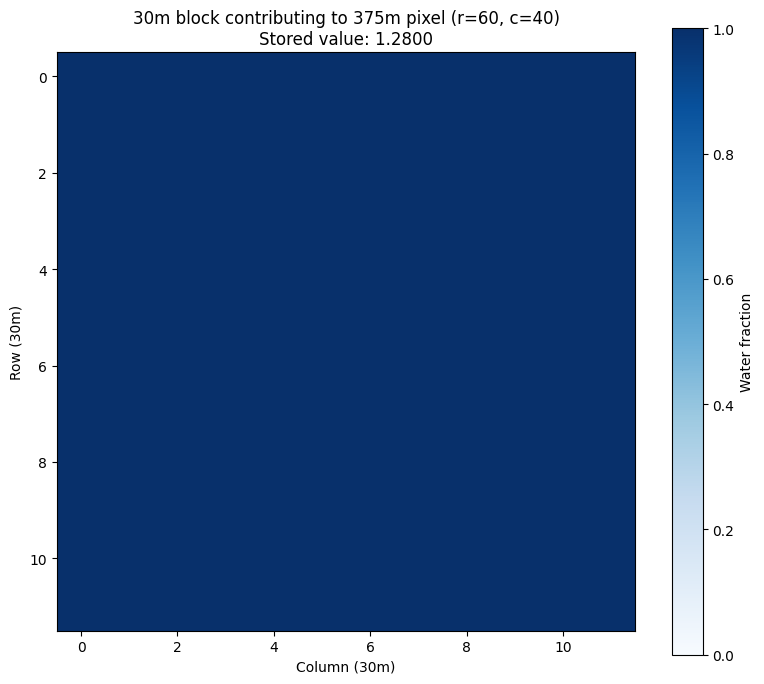

(array([[1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997],
        [1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997],
        [1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997],
        [1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997],
        [1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997],
        [1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
         1.27999997, 1.27999997, 1.27999997, 1.27999997, 1.27999997,
  

In [13]:
# =============================================================================
# Inspect Single 375m Pixel Contribution
# =============================================================================
from rasterio.windows import from_bounds, Window, bounds as window_bounds

def inspect_375m_pixel(
    r,
    c,
    data_30m,
    data_375m,
    transform_30m,
    transform_375m,
):
    """
    Verify how one 375m pixel was computed from contributing 30m pixels.
    Uses transforms (no array slicing ratios). Nodata (NaN) excluded from mean.
    """
    # Bounds of the selected 375m pixel in map coordinates (UTM)
    pix_window = Window(c, r, 1, 1)
    left, bottom, right, top = window_bounds(pix_window, transform_375m)

    # Window on 30m raster that contributes to this 375m pixel
    win_30m = from_bounds(left, bottom, right, top, transform_30m)
    full_win = Window(0, 0, data_30m.shape[1], data_30m.shape[0])
    win_clipped = win_30m.intersection(full_win)

    r0 = int(win_clipped.row_off)
    c0 = int(win_clipped.col_off)
    h = int(win_clipped.height)
    w = int(win_clipped.width)
    block = np.asarray(data_30m[r0 : r0 + h, c0 : c0 + w], dtype=np.float64)

    # Manual mean, excluding nodata (NaN)
    valid = np.isfinite(block)
    manual_mean = np.nanmean(block) if np.any(valid) else np.nan
    stored_value = float(data_375m[r, c])
    diff = (stored_value - manual_mean) if np.isfinite(stored_value) and np.isfinite(manual_mean) else np.nan

    print(f"Selected 375m pixel: (r={r}, c={c})")
    print(f"Stored 375m value:   {stored_value:.6f}")
    print(f"Manual recomputed:   {manual_mean:.6f}")
    print(f"Block shape:         {block.shape} (expect ~12×12)")
    print(f"Difference:          {diff:.6f}")

    # Visualization
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(block, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label="Water fraction")
    ax.set_title(f"30m block contributing to 375m pixel (r={r}, c={c})\nStored value: {stored_value:.4f}")
    ax.set_xlabel("Column (30m)")
    ax.set_ylabel("Row (30m)")
    plt.tight_layout()
    plt.show()

    return block, manual_mean, stored_value


# Load from output files (no dependency on in-memory variables)
with rasterio.open(os.path.join(OUTPUT_DIR, "jrc_utm_30m.tif")) as src:
    data_30m = src.read(1)
    transform_30m = src.transform
    nodata = src.nodata
    if nodata is not None:
        data_30m = np.where(data_30m == nodata, np.nan, data_30m.astype(np.float64))
    else:
        data_30m = data_30m.astype(np.float64)

with rasterio.open(os.path.join(OUTPUT_DIR, "water_fraction_375m.tif")) as src:
    data_375m = src.read(1)
    transform_375m = src.transform
    nodata = src.nodata
    if nodata is not None:
        data_375m = np.where(data_375m == nodata, np.nan, data_375m.astype(np.float64))
    else:
        data_375m = data_375m.astype(np.float64)

inspect_375m_pixel(
    r=60,
    c=40,
    data_30m=data_30m,
    data_375m=data_375m,
    transform_30m=transform_30m,
    transform_375m=transform_375m,
)

LAND PIXEL
  No pixel with value < 0.05 found.

FULL WATER PIXEL
  Index: (r=0, c=5)  Stored value: 1.2800

Selected 375m pixel: (r=0, c=5)
Stored 375m value:   1.280000
Manual recomputed:   1.280000
Block shape:         (12, 12) (expect ~12×12)
Difference:          0.000000


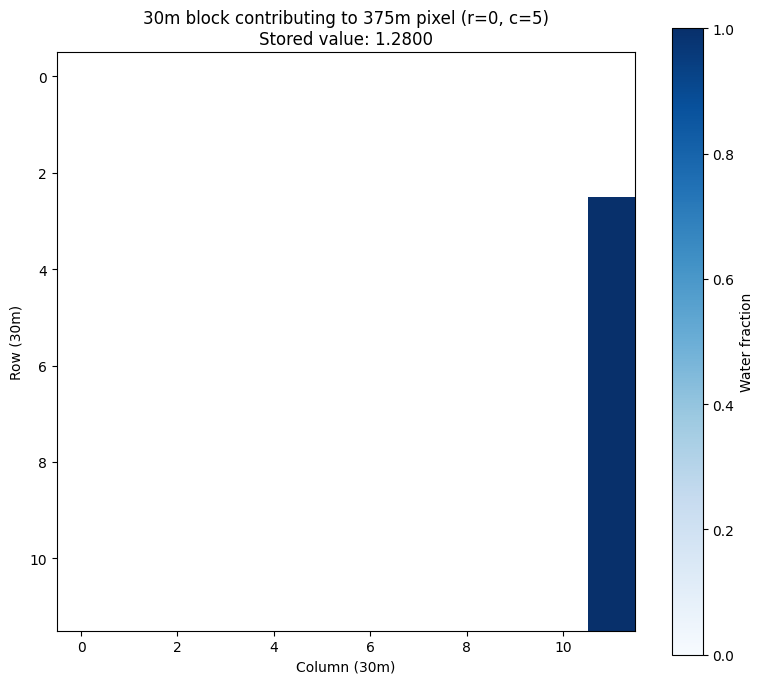


MIXED PIXEL
  Index: (r=94, c=40)  Stored value: 0.4493

Selected 375m pixel: (r=94, c=40)
Stored 375m value:   0.449333
Manual recomputed:   0.421218
Block shape:         (12, 12) (expect ~12×12)
Difference:          0.028115


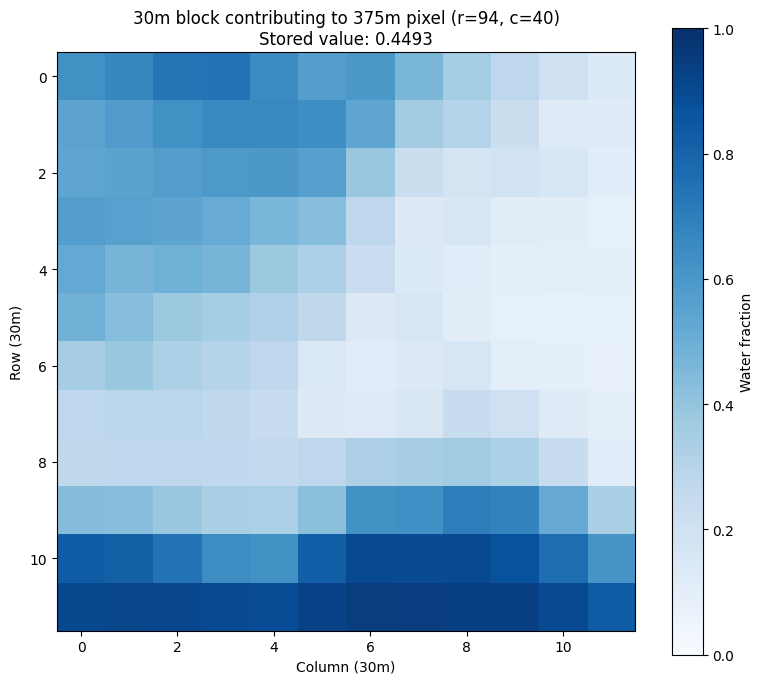

In [14]:
# =============================================================================
# Validate Non-Zero and Mixed 375m Pixels
# =============================================================================
# Load from output files (self-contained, no global overwrite)
with rasterio.open(os.path.join(OUTPUT_DIR, "jrc_utm_30m.tif")) as src:
    _data_30m = src.read(1)
    _transform_30m = src.transform
    _nd = src.nodata
    if _nd is not None:
        _data_30m = np.where(_data_30m == _nd, np.nan, _data_30m.astype(np.float64))
    else:
        _data_30m = _data_30m.astype(np.float64)

with rasterio.open(os.path.join(OUTPUT_DIR, "water_fraction_375m.tif")) as src:
    _data_375m = src.read(1)
    _transform_375m = src.transform
    _nd = src.nodata
    if _nd is not None:
        _data_375m = np.where(_data_375m == _nd, np.nan, _data_375m.astype(np.float64))
    else:
        _data_375m = _data_375m.astype(np.float64)

# All valid (finite) pixels for selection
all_pixels = np.argwhere(np.isfinite(_data_375m))
all_vals = _data_375m[all_pixels[:, 0], all_pixels[:, 1]]
nz_pixels = np.argwhere(np.isfinite(_data_375m) & (_data_375m > 0))
vals = _data_375m[nz_pixels[:, 0], nz_pixels[:, 1]]

# LAND PIXEL (value < 0.05, like the first inspected pixel)
land_idx = np.where(all_vals < 0.05)[0]
if len(land_idx) > 0:
    r_land, c_land = int(all_pixels[land_idx[0], 0]), int(all_pixels[land_idx[0], 1])
    stored_land = float(_data_375m[r_land, c_land])
    print("LAND PIXEL (low water)")
    print(f"  Index: (r={r_land}, c={c_land})  Stored value: {stored_land:.4f}")
    print()
    inspect_375m_pixel(r_land, c_land, _data_30m, _data_375m, _transform_30m, _transform_375m)
else:
    print("LAND PIXEL")
    print("  No pixel with value < 0.05 found.")
    print()

# FULL WATER PIXEL (value > 0.8)
full_idx = np.where(vals > 0.8)[0]
if len(full_idx) > 0:
    r_full, c_full = int(nz_pixels[full_idx[0], 0]), int(nz_pixels[full_idx[0], 1])
    stored_full = float(_data_375m[r_full, c_full])
    print("FULL WATER PIXEL")
    print(f"  Index: (r={r_full}, c={c_full})  Stored value: {stored_full:.4f}")
    print()
    _ = inspect_375m_pixel(r_full, c_full, _data_30m, _data_375m, _transform_30m, _transform_375m)
    print()
else:
    print("FULL WATER PIXEL")
    print("  No pixel with value > 0.8 found.")
    print()

# MIXED PIXEL (0.05 < value < 0.5)
mixed_idx = np.where((vals > 0.05) & (vals < 0.5))[0]
if len(mixed_idx) > 0:
    r_mixed, c_mixed = int(nz_pixels[mixed_idx[0], 0]), int(nz_pixels[mixed_idx[0], 1])
    stored_mixed = float(_data_375m[r_mixed, c_mixed])
    print("MIXED PIXEL")
    print(f"  Index: (r={r_mixed}, c={c_mixed})  Stored value: {stored_mixed:.4f}")
    print()
    _ = inspect_375m_pixel(r_mixed, c_mixed, _data_30m, _data_375m, _transform_30m, _transform_375m)
else:
    print("MIXED PIXEL")
    print("  No pixel with 0.05 < value < 0.5 found.")

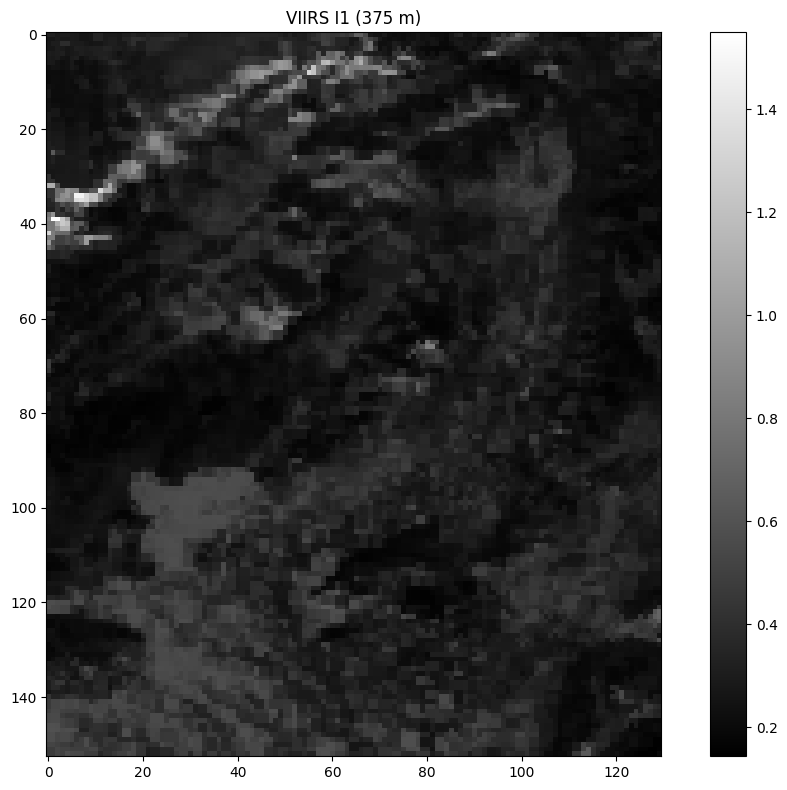

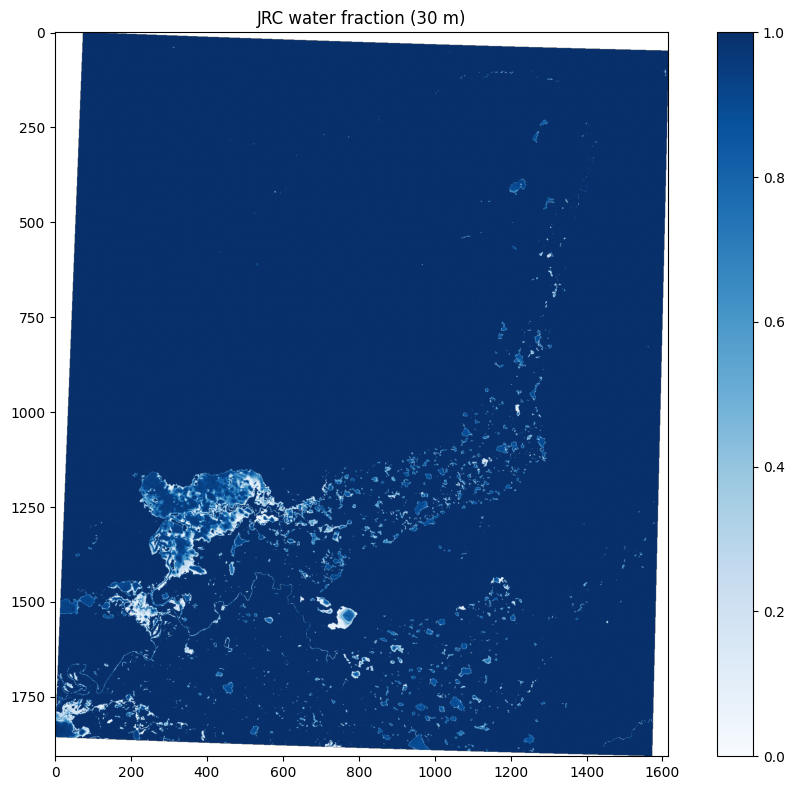

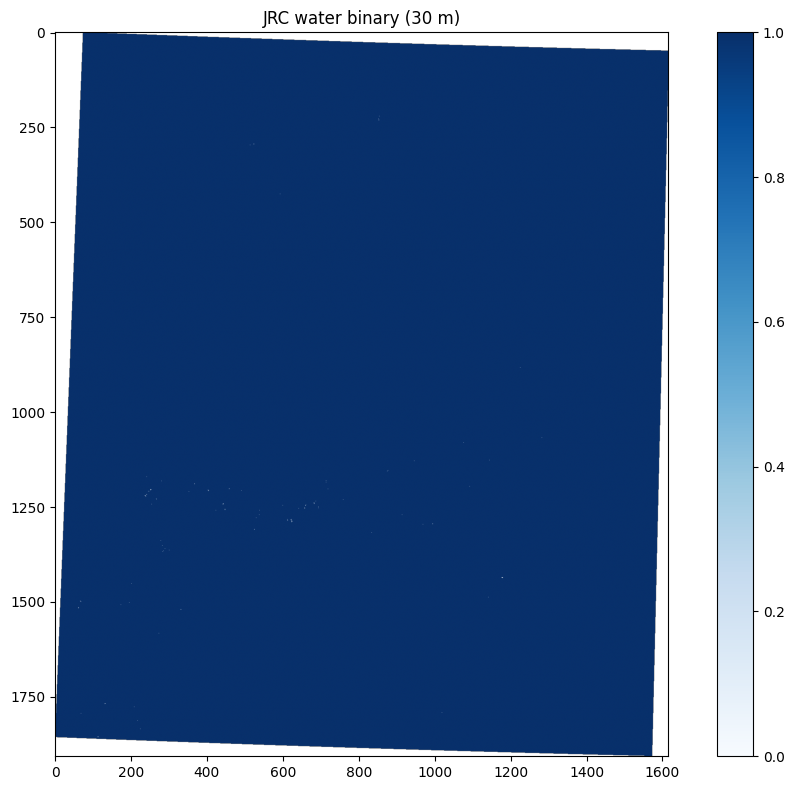

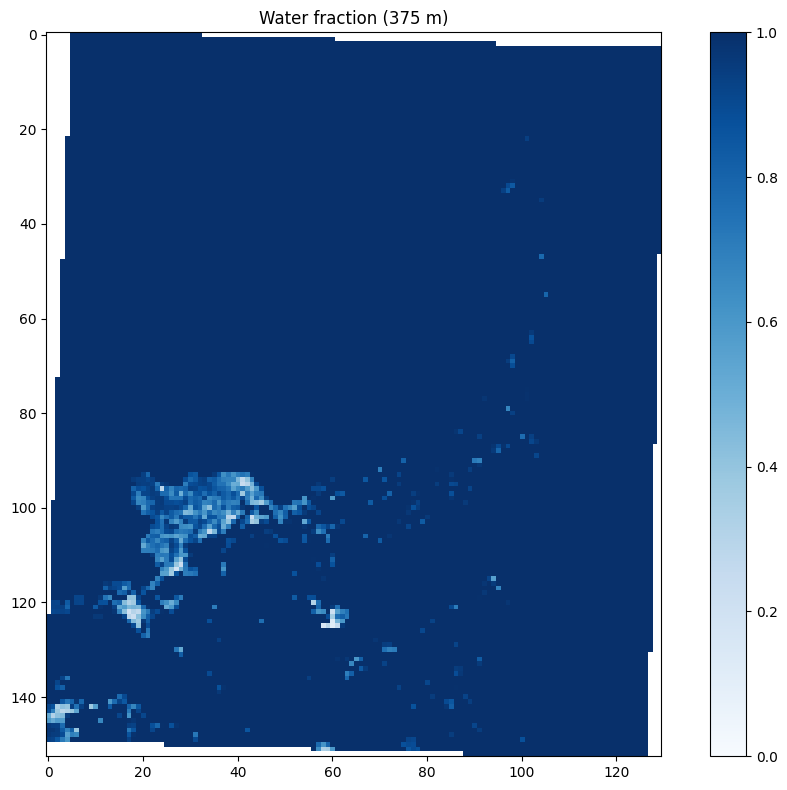

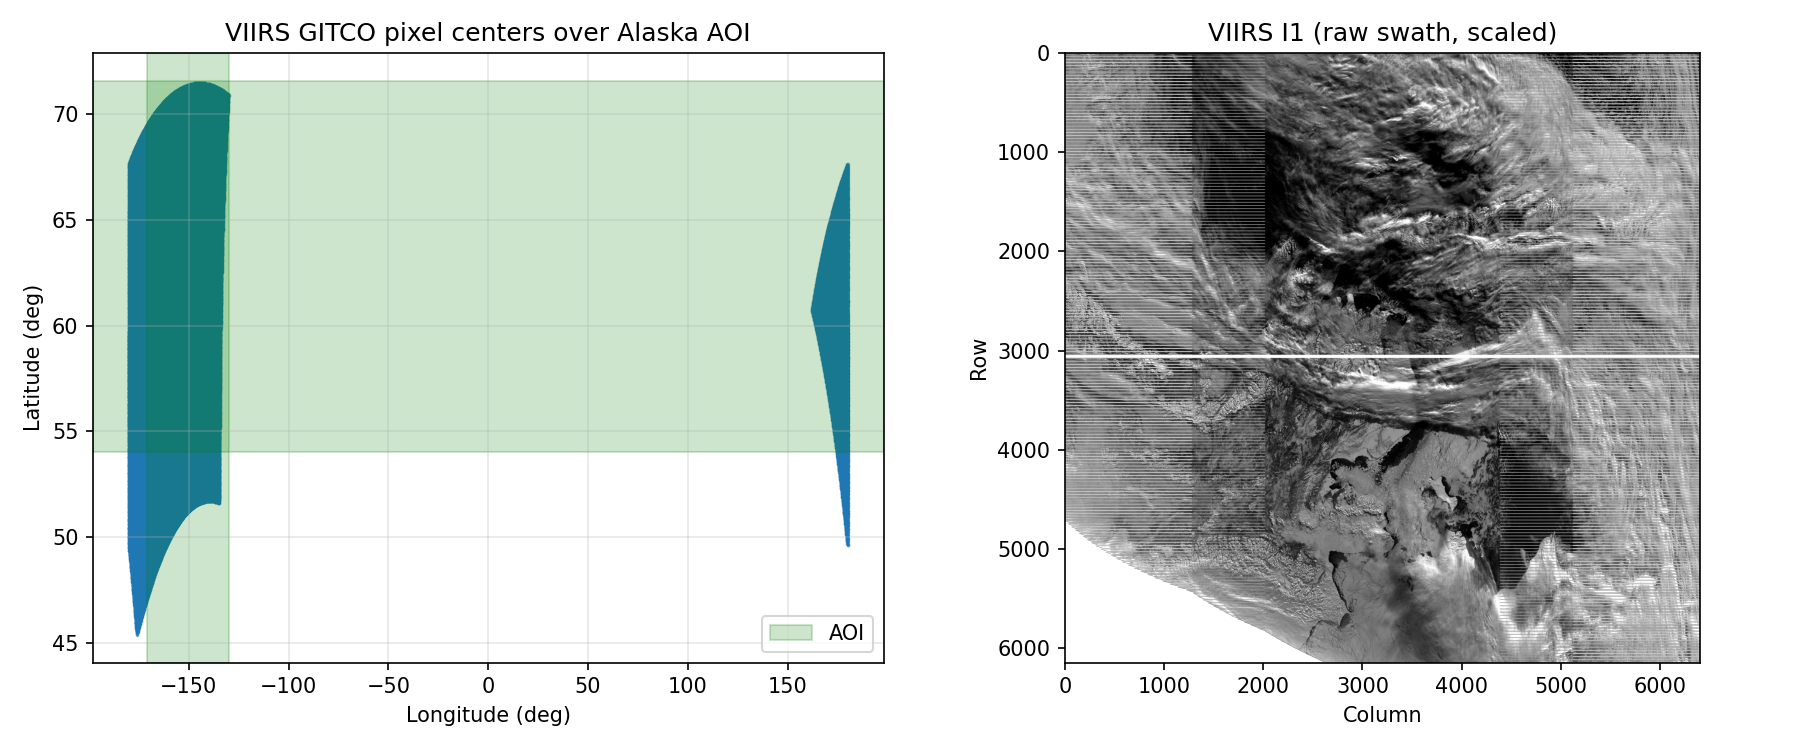

In [15]:
# =============================================================================
# Visualize outputs in Colab
# =============================================================================
def plot_tif(path, title=None, cmap="viridis", vmin=None, vmax=None):
    """Display a single-band GeoTIFF."""
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax)
    ax.set_title(title or path.split("/")[-1])
    plt.tight_layout()
    plt.show()

# VIIRS I1 (375 m)
plot_tif(os.path.join(OUTPUT_DIR, "viirs_projected_375m.tif"), title="VIIRS I1 (375 m)", cmap="gray")

# JRC water fraction (30 m)
plot_tif(os.path.join(OUTPUT_DIR, "jrc_utm_30m.tif"), title="JRC water fraction (30 m)", cmap="Blues", vmin=0, vmax=1)

# JRC binary mask (30 m)
plot_tif(os.path.join(OUTPUT_DIR, "jrc_utm_30m_waterbin.tif"), title="JRC water binary (30 m)", cmap="Blues", vmin=0, vmax=1)

# Water fraction aggregated to 375 m
plot_tif(os.path.join(OUTPUT_DIR, "water_fraction_375m.tif"), title="Water fraction (375 m)", cmap="Blues", vmin=0, vmax=1)

# Step 1 VIIRS raw (PNG)
png_path = os.path.join(OUTPUT_DIR, "step1_viirs_raw.png")
if os.path.exists(png_path):
    from IPython.display import Image, display
    display(Image(png_path))

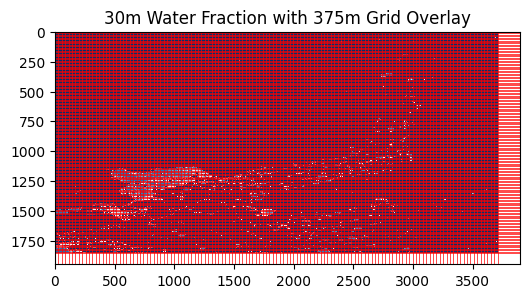

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Downsample indices for display clarity
plt.figure(figsize=(6,6))

plt.imshow(water_frac_30m, origin="upper", cmap="Blues", interpolation="nearest")

# Overlay 375m grid
nrows_375, ncols_375 = water_fraction_375m.shape
h30, w30 = water_frac_30m.shape

# Approximate ratio (should be ~12–13)
row_ratio = h30 / nrows_375
col_ratio = w30 / ncols_375

for i in range(nrows_375 + 1):
    y = i * row_ratio
    plt.axhline(y, color="red", linewidth=0.5)

for j in range(ncols_375 + 1):
    x = j * col_ratio
    plt.axvline(x, color="red", linewidth=0.5)

plt.title("30m Water Fraction with 375m Grid Overlay")
plt.show()

In [17]:
import os

# VIIRS HDF5 path (upload to Colab or use Drive)
HDF5_PATH = "C:\\Users\\daksh\\Desktop\\Research\\RIVERPROJECT\\Source\\GITCO-SVI01-SVI02-SVI03-SVI04-SVI05_npp_d20260125_t2315015_e2320401_b73826_c20260127210812288114_oeac_ops.h5"

# For the one-time *Alaska-wide* EE export ONLY (keep it big, never overwrite it)
ALASKA_EXPORT_BBOX = (54.0, 72.0, -171.0, -129.0)

# Your working AOI (small). Set explicitly, or leave None and compute from VIIRS later.
AOI_BBOX = (65.0, 65.5, -149.5, -148.5)   # OR: AOI_BBOX = None
# CHANGE 4: VIIRS grid resolution (AOI-driven; single source of truth)
RESOLUTION_M = 375.0  # VIIRS I-band nominal resolution

# JRC: we use continuous water_frac_30m = occurrence/100 and two binary masks:
#   water_bin_any  = occurrence >= 1  (any water)
#   water_bin_perm = occurrence >= 50 (permanent water)
# water_bin_30m is set to water_bin_any for compatibility with reprojection step
JRC_BINARY_THRESHOLD = 1  # used for water_bin_30m (= water_bin_any)

# Output directory
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# JRC one-time export: Alaska occurrence GeoTIFF on Drive (from Earth Engine Export)
# Run the "One-time EE export" cell once; then use this path for all runs.
EE_EXPORT_FOLDER = "EarthEngineExports"
JRC_ALASKA_TIF = os.path.join("/content/drive/MyDrive", EE_EXPORT_FOLDER, "jrc_occurrence_alaska_30m.tif")

# Earth Engine: requires a Google Cloud project. Set yours here or via env EARTHENGINE_PROJECT.
# Register at: https://code.earthengine.google.com/register
EE_PROJECT = os.environ.get("EARTHENGINE_PROJECT", "riverprojectnaira")

---
# STEP 1 — Visualize RAW data

1. Read VIIRS swath: I1–I5 (scaled via Factors), lat/lon from GITCO
2. Pull JRC occurrence (0–100) from Earth Engine at 30 m
3. Create water_frac_30m = occurrence/100, optional water_bin_30m
4. Visualize both datasets over Alaska

### 1.1 VIIRS: Discover paths and scaling

In [18]:
def discover_viirs_paths(h5):
    """Find Latitude, Longitude, and I1–I5 band paths in VIIRS GITCO/SVI HDF5."""
    def list_datasets(obj, prefix=""):
        paths = []
        for key in obj.keys():
            p = f"{prefix}/{key}" if prefix else key
            if isinstance(obj[key], h5py.Dataset):
                paths.append(p)
            else:
                paths.extend(list_datasets(obj[key], p))
        return paths

    datasets = list_datasets(h5)
    paths = {}

    # GITCO lat/lon: prefer IMG-GEO-TC
    for kind in ["Latitude", "Longitude"]:
        cand = [p for p in datasets if "GEO" in p and kind in p]
        if cand:
            paths[kind.lower()] = cand[0]
        else:
            cand = [p for p in datasets if "GITCO" in p and kind in p]
            if cand:
                paths[kind.lower()] = cand[0]
    if "latitude" not in paths or "longitude" not in paths:
        raise KeyError("Could not find Latitude/Longitude in HDF5")

    # I1–I3: Reflectance + ReflectanceFactors; I4–I5: BrightnessTemperature + BrightnessTemperatureFactors
    for band in range(1, 6):
        token = f"VIIRS-I{band}-SDR_All"
        if band <= 3:
            names = ["Reflectance", "Radiance"]
        else:
            names = ["BrightnessTemperature", "Radiance"]
        for name in names:
            cand = [p for p in datasets if token in p and p.endswith(name)]
            if cand:
                paths[f"I{band}"] = cand[0]
                break
        if f"I{band}" not in paths:
            raise KeyError(f"Could not find I{band} dataset")

    return paths


def discover_band_scaling(h5, band_path):
    """Get scale/offset from band attrs or companion *Factors dataset."""
    result = {"scale": None, "offset": None, "fill_value": None, "valid_range": None}

    # Band attributes
    attrs = h5[band_path].attrs
    for k, v in attrs.items():
        kk = k.lower()
        if "scale" in kk or kk == "scalefactor":
            result["scale"] = float(np.asarray(v).ravel()[0])
        elif "offset" in kk or kk == "addoffset":
            result["offset"] = float(np.asarray(v).ravel()[0])
        elif "fill" in kk:
            result["fill_value"] = float(np.asarray(v).ravel()[0])
        elif "valid" in kk and "range" in kk:
            arr = np.asarray(v).ravel()
            if arr.size >= 2:
                result["valid_range"] = (float(arr[0]), float(arr[1]))

    # Companion Factors dataset (e.g. ReflectanceFactors = [scale, offset])
    parts = band_path.split("/")
    factors_path = "/".join(parts[:-1]) + "/" + parts[-1] + "Factors"
    if factors_path in h5 and isinstance(h5[factors_path], h5py.Dataset):
        fac = np.asarray(h5[factors_path][...]).ravel()
        if result["scale"] is None and len(fac) >= 1:
            result["scale"] = float(fac[0])
        if result["offset"] is None and len(fac) >= 2:
            result["offset"] = float(fac[1])

    return result


def apply_band_scaling(raw, scaling):
    """Apply scale/offset, mask fill and invalid. Returns float32."""
    out = raw.astype(np.float32, copy=True)
    # CHANGE 1: VIIRS SDR invalid mask (fill/saturated values)
    mask_invalid = (out == 63999) | (out == 65533) | (out > 65529)
    out[mask_invalid] = np.nan
    if scaling.get("fill_value") is not None:
        out[out == scaling["fill_value"]] = np.nan
    if scaling.get("valid_range") is not None:
        vmin, vmax = scaling["valid_range"]
        out[(out < vmin) | (out > vmax)] = np.nan
    s, o = scaling.get("scale"), scaling.get("offset")
    if s is not None and o is not None:
        out = out * s + o
    elif s is not None:
        out = out * s
    elif o is not None:
        out = out + o
    return out

### 1.2 VIIRS: Load geolocation and I1–I5

In [19]:
def load_viirs_swath(hdf5_path):
    """Load lat, lon, and scaled I1–I5 from VIIRS HDF5."""
    hdf5_path = os.path.expanduser(hdf5_path)
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"HDF5 not found: {hdf5_path}")

    with h5py.File(hdf5_path, "r") as h5:
        paths = discover_viirs_paths(h5)
        lat = h5[paths["latitude"]][...].astype(np.float32)
        lon = h5[paths["longitude"]][...].astype(np.float32)

        lat[(lat < -90) | (lat > 90)] = np.nan
        lon[(lon < -180) | (lon > 180)] = np.nan

        bands = {}
        for i in range(1, 6):
            bp = paths[f"I{i}"]
            raw = h5[bp][...]
            scaling = discover_band_scaling(h5, bp)
            bands[f"I{i}"] = apply_band_scaling(raw, scaling)

    print(f"VIIRS shape: {lat.shape}")
    print(f"Lat: {np.nanmin(lat):.4f} to {np.nanmax(lat):.4f}")
    print(f"Lon: {np.nanmin(lon):.4f} to {np.nanmax(lon):.4f}")
    return lat, lon, bands


lat, lon, viirs_bands = load_viirs_swath(HDF5_PATH)

# Compute WORKING AOI_BBOX from VIIRS swath restricted to Alaska (avoids dateline wrap)
# Then add small padding so JRC crop fully covers the swath.
ALASKA_LAT_MIN, ALASKA_LAT_MAX, ALASKA_LON_MIN, ALASKA_LON_MAX = ALASKA_EXPORT_BBOX
in_alaska = (
    np.isfinite(lat) & np.isfinite(lon) &
    (lat >= ALASKA_LAT_MIN) & (lat <= ALASKA_LAT_MAX) &
    (lon >= ALASKA_LON_MIN) & (lon <= ALASKA_LON_MAX)
)
if not np.any(in_alaska):
    raise ValueError("No VIIRS pixels inside Alaska bbox. Check lat/lon or ALASKA_EXPORT_BBOX.")
lat_in = np.nanmin(lat[in_alaska]), np.nanmax(lat[in_alaska])
lon_in = np.nanmin(lon[in_alaska]), np.nanmax(lon[in_alaska])
PAD_DEG = 0.05
lat_min = max(ALASKA_LAT_MIN, lat_in[0] - PAD_DEG)
lat_max = min(ALASKA_LAT_MAX, lat_in[1] + PAD_DEG)
lon_min = max(ALASKA_LON_MIN, lon_in[0] - PAD_DEG)
lon_max = min(ALASKA_LON_MAX, lon_in[1] + PAD_DEG)
AOI_BBOX = (lat_min, lat_max, lon_min, lon_max)

# For overlap checks and plotting, use this working AOI extent
viirs_lat_min, viirs_lat_max = lat_min, lat_max
viirs_lon_min, viirs_lon_max = lon_min, lon_max
print(f"AOI_BBOX (VIIRS-over-Alaska + {PAD_DEG}° padding): lat [{lat_min:.4f}, {lat_max:.4f}], lon [{lon_min:.4f}, {lon_max:.4f}]")
print("OK: VIIRS swath overlaps AOI_BBOX")

VIIRS shape: (6144, 6400)
Lat: 45.3534 to 71.5430
Lon: -179.9999 to 179.9999
AOI_BBOX (VIIRS-over-Alaska + 0.05° padding): lat [54.0000, 71.5930], lon [-171.0000, -129.9900]
OK: VIIRS swath overlaps AOI_BBOX


### 1.3 VIIRS: Plot lat/lon scatter and raw I1

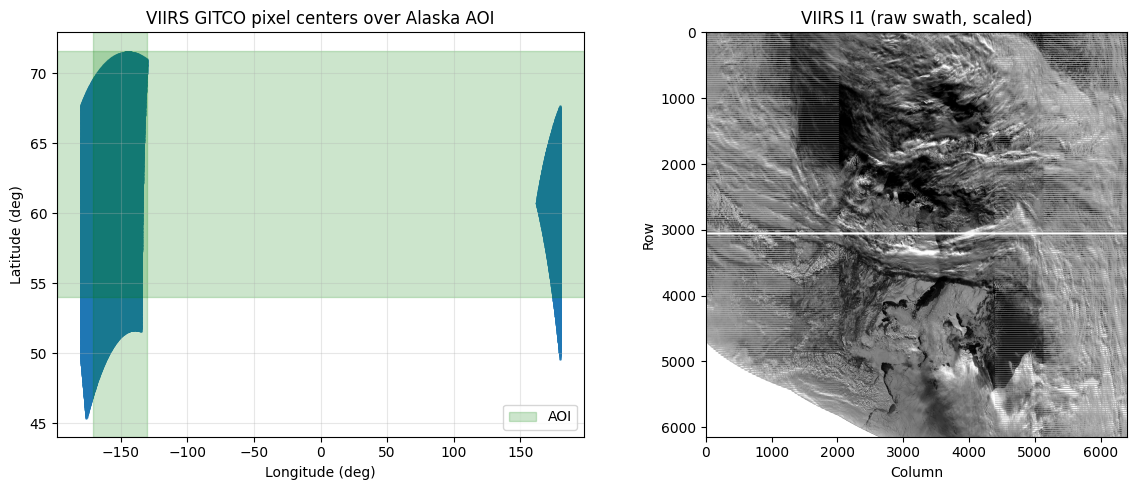

Saved: outputs/step1_viirs_raw.png


In [20]:
# Downsample for fast plotting
step = max(1, lat.shape[0] // 500)
lat_ds = lat[::step, ::step]
lon_ds = lon[::step, ::step]
valid = np.isfinite(lat_ds) & np.isfinite(lon_ds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Lat/lon scatter over Alaska
ax1.scatter(lon_ds[valid], lat_ds[valid], s=0.5, alpha=0.5)
lat_min, lat_max, lon_min, lon_max = AOI_BBOX
ax1.axvspan(lon_min, lon_max, alpha=0.2, color="green", label="AOI")
ax1.axhspan(lat_min, lat_max, alpha=0.2, color="green")
ax1.set_xlabel("Longitude (deg)")
ax1.set_ylabel("Latitude (deg)")
ax1.set_title("VIIRS GITCO pixel centers over Alaska AOI")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Raw I1 swath
i1 = viirs_bands["I1"]
vmin, vmax = np.nanpercentile(i1, 2), np.nanpercentile(i1, 98)
ax2.imshow(i1, cmap="gray", vmin=vmin, vmax=vmax)
ax2.set_title("VIIRS I1 (raw swath, scaled)")
ax2.set_xlabel("Column")
ax2.set_ylabel("Row")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step1_viirs_raw.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/step1_viirs_raw.png")

### 1.4a One-time: Export JRC occurrence for Alaska to Drive (run once)

Run the cell below **once** to export JRC Global Surface Water "occurrence" for Alaska to Google Drive. After the task completes in the Earth Engine Tasks tab, use the local GeoTIFF for all runs (no more 262,144 pixel limit).


In [ ]:
# One-time export: JRC occurrence for Alaska (scale=30 m, save locally with tiling)
# Uses 0.5° × 0.5° tiles to stay under 32768 pixel limit at 30m resolution
def _init_ee_for_export():
    if ee is None:
        raise ImportError("earthengine-api not installed. Run: pip install earthengine-api")
    project = os.environ.get("EARTHENGINE_PROJECT") or EE_PROJECT
    if project == "your-gcp-project-id":
        raise ValueError("Set EE_PROJECT in the Parameters cell.")
    try:
        ee.Initialize(project=project)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=project)

_init_ee_for_export()
alaska_lat_min, alaska_lat_max, alaska_lon_min, alaska_lon_max = ALASKA_EXPORT_BBOX

# Create grid of 0.5° tiles (at 30m: 0.5° ≈ 1,850 px, well under 32768 limit)
tile_size_deg = 0.5
import urllib.request
os.makedirs(JRC_EXPORT_DIR, exist_ok=True)

lat_tiles = []
lon_tiles = []
lat = alaska_lat_min
while lat < alaska_lat_max:
    lat_tiles.append((lat, min(lat + tile_size_deg, alaska_lat_max)))
    lat += tile_size_deg
lon = alaska_lon_min
while lon < alaska_lon_max:
    lon_tiles.append((lon, min(lon + tile_size_deg, alaska_lon_max)))
    lon += tile_size_deg

gsw = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence")
total_tiles = len(lat_tiles) * len(lon_tiles)
tile_idx = 0
successful = 0

print(f"Downloading {total_tiles} tiles at 30m resolution...\n")

for lat_min, lat_max in lat_tiles:
    for lon_min, lon_max in lon_tiles:
        tile_geom = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])
        try:
            url = gsw.clip(tile_geom).getDownloadUrl({
                'scale': 30,
                'crs': 'EPSG:4326',
                'region': tile_geom,
                'format': 'GEO_TIFF'
            })
            output_path = os.path.join(JRC_EXPORT_DIR, f"jrc_occurrence_alaska_30m-{tile_idx:06d}.tif")
            print(f"[{tile_idx:3d}/{total_tiles}] Tile lat [{lat_min:.1f}, {lat_max:.1f}], lon [{lon_min:.1f}, {lon_max:.1f}]...", end=" ", flush=True)
            urllib.request.urlretrieve(url, output_path)
            print("✓")
            successful += 1
        except Exception as e:
            print(f"✗ ({str(e)[:40]})")
        tile_idx += 1

print(f"\n✓ Downloaded {successful}/{total_tiles} tiles to: {JRC_EXPORT_DIR}")


[  0/3024] Tile lat [54.0, 54.5], lon [-171.0, -170.5]... ✓
[  1/3024] Tile lat [54.0, 54.5], lon [-170.5, -170.0]... ✓
[  2/3024] Tile lat [54.0, 54.5], lon [-170.0, -169.5]... ✓
[  3/3024] Tile lat [54.0, 54.5], lon [-169.5, -169.0]... ✓
[  4/3024] Tile lat [54.0, 54.5], lon [-169.0, -168.5]... ✓
[  5/3024] Tile lat [54.0, 54.5], lon [-168.5, -168.0]... ✓
[  6/3024] Tile lat [54.0, 54.5], lon [-168.0, -167.5]... ✓
[  7/3024] Tile lat [54.0, 54.5], lon [-167.5, -167.0]... ✓
[  8/3024] Tile lat [54.0, 54.5], lon [-167.0, -166.5]... ✓
[  9/3024] Tile lat [54.0, 54.5], lon [-166.5, -166.0]... ✓
[ 10/3024] Tile lat [54.0, 54.5], lon [-166.0, -165.5]... ✓
[ 11/3024] Tile lat [54.0, 54.5], lon [-165.5, -165.0]... ✓
[ 12/3024] Tile lat [54.0, 54.5], lon [-165.0, -164.5]... ✓
[ 13/3024] Tile lat [54.0, 54.5], lon [-164.5, -164.0]... 

### 1.4 JRC: Pull occurrence from Earth Engine (0–100, 30 m)

In [ ]:
import os, glob

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EE_EXPORT_FOLDER = "EarthEngineExports"
JRC_EXPORT_DIR = os.path.join("C:/Users/daksh/Desktop/Research/RIVERPROJECT/Source/EarthEngineExports", EE_EXPORT_FOLDER)

# Earth Engine export produces multiple tiled GeoTIFFs like:
# jrc_occurrence_alaska_30m-0000000000-0000065536.tif
JRC_TILE_GLOB = os.path.join(JRC_EXPORT_DIR, "jrc_occurrence_alaska_30m-*.tif")

# Alaska-wide export bounds (ONLY for exporting/tiling; should not equal AOI_BBOX)
# (lat_min, lat_max, lon_min, lon_max)
ALASKA_EXPORT_BBOX = (54.0, 72.0, -171.0, -129.0)

# Working AOI: set later from VIIRS swath in Step 1.2
# Keep None so we don't accidentally use a huge bbox or trip guards.
AOI_BBOX = None

In [ ]:
# Earth Engine init (used by the one-time export cell). No sampleRectangle — JRC from local GeoTIFF.

def init_earth_engine(project=None):
    """Initialize Google Earth Engine. Uses EE_PROJECT from Parameters cell."""
    if ee is None:
        raise ImportError("earthengine-api not installed. Run: pip install earthengine-api")
    project = project or os.environ.get("EARTHENGINE_PROJECT") or EE_PROJECT
    if project == "your-gcp-project-id":
        raise ValueError(
            "Set EE_PROJECT to your Google Cloud project ID (Parameters cell). "
            "Register at: https://code.earthengine.google.com/register"
        )
    try:
        ee.Initialize(project=project)
        print("Earth Engine initialized.")
    except Exception as e:
        if "no project found" in str(e).lower() or "project" in str(e).lower():
            raise ValueError(
                f"Earth Engine needs a valid project. Set EE_PROJECT in the Parameters cell. Error: {e}"
            ) from e
        print("Authenticate: ee.Authenticate()")
        ee.Authenticate()
        ee.Initialize(project=project)
        print("Earth Engine initialized.")


def load_jrc_crop_from_drive(aoi_bbox, tif_path):
    """
    Read the Alaska JRC occurrence GeoTIFF from Drive and crop to AOI_BBOX.
    Uses rasterio so we only load the VIIRS-overlap window (no 262k pixel limit).
    Returns: occurrence_30m (0–100), jrc_bounds (west, south, east, north), jrc_crs.
    """

    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    if (lat_max - lat_min) > 5 or (lon_max - lon_min) > 10:
      raise ValueError(
        "AOI_BBOX is too large for Colab. Use a smaller AOI (few degrees max)."
    )
    west, south, east, north = lon_min, lat_min, lon_max, lat_max
    if not os.path.exists(tif_path):
        raise FileNotFoundError(
            f"JRC Alaska GeoTIFF not found: {tif_path}. "
            "Run the 'One-time EE export' cell and wait for the task to complete."
        )
    with rasterio.open(tif_path) as src:
        jrc_crs = src.crs
        # Crop to AOI using window so we only load the needed window
        from rasterio.windows import from_bounds
        window = from_bounds(west, south, east, north, src.transform)
        window = window.intersection(rasterio.windows.Window(0, 0, src.width, src.height))
        occ = src.read(1, window=window)
        # Bounds of the cropped window in geographic coords
        from rasterio.windows import transform as window_transform
        win_transform = window_transform(window, src.transform)
        w, h = int(window.width), int(window.height)
        west_c = win_transform.c
        north_c = win_transform.f
        east_c = win_transform.c + w * win_transform.a
        south_c = win_transform.f + h * win_transform.e
        jrc_bounds = (west_c, south_c, east_c, north_c)
    # JRC raw uses 255 for nodata; treat as nan for consistency
    occurrence_30m = np.where(occ == 255, np.nan, occ.astype(np.float32))
    print(f"JRC occurrence shape (cropped): {occurrence_30m.shape}")
    valid = np.isfinite(occurrence_30m)
    if np.any(valid):
        print(f"Occurrence range (valid): {np.nanmin(occurrence_30m):.1f} to {np.nanmax(occurrence_30m):.1f}")
    return occurrence_30m, jrc_bounds, jrc_crs

In [ ]:
# --- JRC tiled GeoTIFF loader (RAM-safe): crop during merge, no full mosaic in memory ---

import os, glob
import numpy as np
import rasterio
from rasterio.merge import merge

def bbox_intersects(bounds, aoi_bbox):
    """bounds: (left, bottom, right, top) in EPSG:4326"""
    left, bottom, right, top = bounds
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    aoi_left, aoi_bottom, aoi_right, aoi_top = lon_min, lat_min, lon_max, lat_max
    return not (right < aoi_left or left > aoi_right or top < aoi_bottom or bottom > aoi_top)

def find_jrc_tiles_for_aoi(aoi_bbox, tile_glob):
    paths = sorted(glob.glob(tile_glob))
    if not paths:
        raise FileNotFoundError(
            f"No JRC tiles found at: {tile_glob}\n"
            f"Check Drive folder: {os.path.dirname(tile_glob)}"
        )

    hit = []
    for p in paths:
        with rasterio.open(p) as src:
            if src.crs is None:
                continue
            if bbox_intersects(src.bounds, aoi_bbox):
                hit.append(p)

    if not hit:
        raise FileNotFoundError(
            "No JRC tiles intersect your AOI_BBOX.\n"
            f"AOI_BBOX={aoi_bbox}\n"
            f"Tiles searched: {len(paths)}"
        )

    return hit

def load_jrc_crop_from_drive_safe(aoi_bbox, tile_glob, max_pixels=80_000_000):
    """
    Loads JRC occurrence cropped to AOI from tiled Alaska export.

    RAM-safe fix:
    - Crops DURING merge via merge(..., bounds=...), instead of building a full mosaic then cropping.
    - Avoids rasterio MemoryFile / full mosaic materialization.
    """
    # Guard 1: refuse if user passes the Alaska-wide bbox (too big for Colab)
    if aoi_bbox == ALASKA_EXPORT_BBOX:
        raise ValueError(
            "AOI_BBOX equals ALASKA_EXPORT_BBOX. This usually means you overwrote one with the other.\n"
            "Fix: keep ALASKA_EXPORT_BBOX as the Alaska-wide export bbox, and set AOI_BBOX to a smaller working AOI\n"
            "(or run VIIRS Step 1.2 to compute AOI_BBOX from the swath)."
        )

    # Guard 2: sanity check that ALASKA_EXPORT_BBOX is actually Alaska-sized
    if (ALASKA_EXPORT_BBOX[1] - ALASKA_EXPORT_BBOX[0]) < 2.0:
        raise ValueError(
            "ALASKA_EXPORT_BBOX looks incorrectly small (it may have been overwritten).\n"
            "Reset ALASKA_EXPORT_BBOX to (54.0, 72.0, -171.0, -129.0)."
        )

    # AOI bounds (EPSG:4326)
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    west, south, east, north = lon_min, lat_min, lon_max, lat_max

    tile_paths = find_jrc_tiles_for_aoi(aoi_bbox, tile_glob)

    # Open tiles and crop during merge (RAM-safe)
    srcs = [rasterio.open(p) for p in tile_paths]
    try:
        crs = srcs[0].crs
        if crs is None:
            raise ValueError("JRC tiles have no CRS. Re-export from Earth Engine with a CRS (EPSG:4326).")

        # This returns ONLY the mosaic window intersecting bounds (west,south,east,north)
        mosaic, mosaic_transform = merge(srcs, bounds=(west, south, east, north))  # (1, H, W)
        arr = mosaic[0].astype(np.uint8)

        # Safety: refuse huge crops (still possible if AOI is large)
        n_pix = int(arr.shape[0]) * int(arr.shape[1])
        if n_pix > max_pixels:
            raise MemoryError(
                f"Requested AOI crop is too large: {arr.shape[1]} x {arr.shape[0]} = {n_pix:,} pixels.\n"
                "Reduce AOI_BBOX or lower the AOI size before loading."
            )

        # Return requested bounds (note: exact raster bounds may differ by <1 pixel)
        bounds = (west, south, east, north)
        return arr, bounds, crs

    finally:
        for s in srcs:
            s.close()

In [ ]:
# --- Load cropped JRC occurrence from tiled Alaska export ---
if AOI_BBOX is None:
    raise ValueError("AOI_BBOX is None. Run Step 1.2 (VIIRS load) first to set AOI_BBOX.")

# Fix path: tiles are directly in EarthEngineExports, not in a nested subfolder
JRC_TILE_GLOB_FIXED = os.path.join(
    "C:/Users/daksh/Desktop/Research/RIVERPROJECT/Source/EarthEngineExports",
    "jrc_occurrence_alaska_30m-*.tif"
)

# ── SAFETY: clamp AOI to a small working window ──────────────────────────────
# AOI_BBOX may have been set to the full Alaska swath extent by cell 17.
# Clamp to at most 2° lat × 2° lon centered on the fixed working area.
_lat_min, _lat_max, _lon_min, _lon_max = AOI_BBOX
_lat_span = _lat_max - _lat_min
_lon_span = _lon_max - _lon_min
_MAX_SPAN = 2.0  # degrees

if _lat_span > _MAX_SPAN or _lon_span > _MAX_SPAN:
    print(f"WARNING: AOI_BBOX span ({_lat_span:.2f}° lat x {_lon_span:.2f}° lon) is too large.")
    print("Clamping to fixed small AOI: lat [65.0, 65.5], lon [-149.5, -148.5]")
    AOI_BBOX = (65.0, 65.5, -149.5, -148.5)
    _lat_min, _lat_max, _lon_min, _lon_max = AOI_BBOX
# ─────────────────────────────────────────────────────────────────────────────

occ_u8, jrc_bounds, jrc_crs = load_jrc_crop_from_drive_safe(AOI_BBOX, JRC_TILE_GLOB_FIXED)

JRC_NODATA = 255
valid = (occ_u8 != JRC_NODATA)

# Convert to float + mask nodata as NaN for clean stats/math
occurrence_30m = occ_u8.astype(np.float32)
occurrence_30m[~valid] = np.nan

print("Loaded JRC crop:", occurrence_30m.shape, jrc_crs, jrc_bounds)
if np.any(valid):
    print(f"Occurrence range (valid): {np.nanmin(occurrence_30m):.1f} – {np.nanmax(occurrence_30m):.1f}")
else:
    print("WARNING: No valid pixels in JRC crop (all nodata). Check AOI vs tiles.")

# Continuous fractional water in [0,1]
water_frac_30m = occurrence_30m / 100.0  # float, NaNs preserved

# Binary masks (uint8) with nodata kept as 255 for future GeoTIFF writing
water_bin_any  = np.where(valid, (occ_u8 >= 1).astype(np.uint8), JRC_NODATA).astype(np.uint8)
water_bin_perm = np.where(valid, (occ_u8 >= 50).astype(np.uint8), JRC_NODATA).astype(np.uint8)

# Stats
n_valid = int(valid.sum())
print("Valid pixels:", n_valid, "/", occ_u8.size)
if n_valid > 0:
    pct_any  = 100.0 * np.sum((occ_u8 >= 1) & valid) / n_valid
    pct_perm = 100.0 * np.sum((occ_u8 >= 50) & valid) / n_valid
    print(f"Water % (occurrence>=1):  {pct_any:.2f}%")
    print(f"Water % (occurrence>=50): {pct_perm:.2f}%")

# Overlap check
a_lat_min, a_lat_max, a_lon_min, a_lon_max = AOI_BBOX
jrc_west, jrc_south, jrc_east, jrc_north = jrc_bounds
jrc_covers_aoi = (jrc_west <= a_lon_max and jrc_east >= a_lon_min and
                  jrc_south <= a_lat_max and jrc_north >= a_lat_min)

print(f"AOI_BBOX: lat [{a_lat_min:.4f}, {a_lat_max:.4f}], lon [{a_lon_min:.4f}, {a_lon_max:.4f}]")
print(f"JRC:     lat [{jrc_south:.4f}, {jrc_north:.4f}], lon [{jrc_west:.4f}, {jrc_east:.4f}]")
print(f"VIIRS:   lat [{viirs_lat_min:.4f}, {viirs_lat_max:.4f}], lon [{viirs_lon_min:.4f}, {viirs_lon_max:.4f}]")
print("OK: JRC covers AOI_BBOX" if jrc_covers_aoi else "WARNING: JRC may not fully cover AOI.")

NameError: name 'AOI_BBOX' is not defined

### 1.5 JRC: Save occurrence GeoTIFF and visualize

In [ ]:
from rasterio.transform import from_bounds as transform_from_bounds

def save_geotiff(arr, bounds, path, dtype=None, nodata=None):
    """Save 2D array to GeoTIFF. bounds = (west, south, east, north)."""
    h, w = arr.shape
    west, south, east, north = bounds
    transform = transform_from_bounds(west, south, east, north, w, h)
    dtype = dtype or arr.dtype
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with rasterio.open(
        path, "w", driver="GTiff", height=h, width=w, count=1,
        dtype=dtype, crs="EPSG:4326", transform=transform, nodata=nodata
    ) as dst:
        dst.write(arr.astype(dtype), 1)
    print(f"Saved: {path}")


# Save raw occurrence (0–100)
occ_to_save = np.where(np.isfinite(occurrence_30m), occurrence_30m, 255.0).astype(np.float32)
save_geotiff(occ_to_save, jrc_bounds, os.path.join(OUTPUT_DIR, "jrc_occurrence_30m.tif"), nodata=255.0)

# Visualize occurrence, water fraction, and both binary masks
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

im0 = axes[0, 0].imshow(occurrence_30m, cmap="Blues", vmin=0, vmax=100)
axes[0, 0].set_title("JRC occurrence (0–100%)")
plt.colorbar(im0, ax=axes[0, 0], label="%")

im1 = axes[0, 1].imshow(water_frac_30m, cmap="Blues", vmin=0, vmax=1)
axes[0, 1].set_title("Water fraction (0–1)")
plt.colorbar(im1, ax=axes[0, 1], label="Fraction")

im2 = axes[1, 0].imshow(np.where(water_bin_any == 255, np.nan, water_bin_any), cmap="Blues", vmin=0, vmax=1)
axes[1, 0].set_title("Binary: occurrence ≥ 1 (any water)")
plt.colorbar(im2, ax=axes[1, 0], label="0=land, 1=water")

im3 = axes[1, 1].imshow(np.where(water_bin_perm == 255, np.nan, water_bin_perm), cmap="Blues", vmin=0, vmax=1)
axes[1, 1].set_title("Binary: occurrence ≥ 50 (permanent)")
plt.colorbar(im3, ax=axes[1, 1], label="0=land, 1=water")

for ax in axes.flat:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

fig.suptitle("JRC: occurrence is continuous (0–100%). Pink/in-between shades = intermediate %, not a third class.", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step1_jrc_raw.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/step1_jrc_raw.png")
print("Note: Intermediate occurrence values (e.g. 1–49%) are continuous, not a third class; 'pink' pixels are just in-between % water.")


---
# STEP 2 — Reproject BOTH datasets to same UTM CRS

1. Choose UTM zone from AOI center
2. Reproject VIIRS swath → 375 m grid (I1–I5)
3. Reproject JRC to 30 m UTM (bilinear for water_frac, nearest for binary)
4. Visualize side-by-side in projected meters

### 2.1 Choose UTM and reproject VIIRS

In [ ]:
def choose_utm_crs(lon0, lat0):
    """UTM zone from center (lon0, lat0). Alaska center ~zone 6."""
    zone = int((lon0 + 180) / 6) + 1
    epsg = 32600 + zone if lat0 >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)


# CHANGE 2: pyresample nearest-neighbor (professor-aligned: radius_of_influence=7000, epsilon=0.375)
def swath_to_grid(lat, lon, values, dst_crs, dst_res_m, bbox_latlon):
    """Resample VIIRS swath onto UTM grid via pyresample nearest-neighbor."""
    if geometry is None or image is None:
        raise ImportError("pyresample required. Run: pip install pyresample")
    lat_min, lat_max, lon_min, lon_max = bbox_latlon
    trans_to_utm = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)

    buf = 0.5
    in_aoi = (
        (lat >= lat_min - buf) & (lat <= lat_max + buf) &
        (lon >= lon_min - buf) & (lon <= lon_max + buf)
    )
    valid = np.isfinite(lat) & np.isfinite(lon) & np.isfinite(values) & in_aoi
    lats_m = np.ma.masked_array(lat, mask=~valid)
    lons_m = np.ma.masked_array(lon, mask=~valid)
    data_m = np.ma.masked_array(values.astype(np.float32), mask=~valid)

    corners_ll = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)]
    corners_utm = [trans_to_utm.transform(x, y) for x, y in corners_ll]
    x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
    y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)

    width = max(1, int(np.ceil((x_max - x_min) / dst_res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / dst_res_m)))
    area_extent = (x_min, y_min, x_max, y_max)
    lon0, lat0 = 0.5 * (lon_min + lon_max), 0.5 * (lat_min + lat_max)
    zone = int((lon0 + 180) / 6) + 1
    proj_dict = {"proj": "utm", "zone": zone, "ellps": "WGS84", "units": "m"}
    area_def = geometry.AreaDefinition("viirs_utm", "VIIRS UTM", "viirs_utm", proj_dict, width, height, area_extent)
    swath_def = geometry.SwathDefinition(lons=lons_m, lats=lats_m)

    swath_con = image.ImageContainerNearest(data_m, swath_def, radius_of_influence=7000, epsilon=0.375, nprocs=1)
    area_con = swath_con.resample(area_def)
    arr = area_con.image_data
    result = np.ma.filled(arr, fill_value=np.nan).astype(np.float32) if np.ma.is_masked(arr) else np.asarray(arr, dtype=np.float32)

    # Use rasterio.transform.from_bounds (not windows.from_bounds)
    from rasterio.transform import from_bounds as transform_from_bounds
    transform = transform_from_bounds(x_min, y_min, x_max, y_max, width, height)
    return result, transform

In [ ]:

##Summary of fixes applied:

# 2D meshgrid issue: Changed from passing 1D lat/lon arrays to swath_to_grid to creating proper 2D meshgrids using np.meshgrid(lon_1d, lat_1d). The pyresample SwathDefinition requires 2D coordinate arrays.

# Import shadowing issue: The from_bounds import from rasterio.windows (in an earlier cell) was shadowing the from_bounds from rasterio.transform. Fixed by explicitly importing from_bounds from the transform module within the swath_to_grid function.

# Dynamic filename: The code now correctly uses f"viirs_projected_stack_{int(RESOLUTION_M)}m.tif" instead of a hardcoded "375m" filename.

# Result: VIIRS data (5 bands I1-I5) successfully reprojected to UTM zone 6 at 375m resolution with proper filename: viirs_projected_stack_375m.tif


lat_min, lat_max, lon_min, lon_max = AOI_BBOX
lon0 = 0.5 * (lon_min + lon_max)
lat0 = 0.5 * (lat_min + lat_max)
utm_crs = choose_utm_crs(lon0, lat0)
print(f"UTM CRS: {utm_crs}")

# Create 1D arrays for VIIRS swath extent
lat_1d = np.linspace(viirs_lat_min, viirs_lat_max, i1.shape[0])
lon_1d = np.linspace(viirs_lon_min, viirs_lon_max, i1.shape[1])

# Create 2D meshgrid for swath_to_grid (pyresample requires 2D lat/lon)
lon_2d, lat_2d = np.meshgrid(lon_1d, lat_1d)

# Reproject I1–I5 using RESOLUTION_M (AOI-driven grid)
viirs_grids = {}
ref_transform = None
for i in range(1, 6):
    grid, transform = swath_to_grid(lat_2d, lon_2d, viirs_bands[f"I{i}"], utm_crs, RESOLUTION_M, AOI_BBOX)
    viirs_grids[f"I{i}"] = grid
    if ref_transform is None:
        ref_transform = transform

# Grid summary (AOI + resolution = single source of truth)
h, w = viirs_grids["I1"].shape
print(f"Grid: {w}×{h} pixels at {RESOLUTION_M} m (AOI-driven)")

# Stack I1–I5 and save
stack = np.stack([viirs_grids[f"I{i}"] for i in range(1, 6)], axis=0)
nodata = -9999.0
stack_filled = np.where(np.isfinite(stack), stack, nodata).astype(np.float32)

h, w = stack.shape[1], stack.shape[2]
output_filename = f"viirs_projected_stack_{int(RESOLUTION_M)}m.tif"
with rasterio.open(
    os.path.join(OUTPUT_DIR, output_filename), "w",
    driver="GTiff", height=h, width=w, count=5, dtype=np.float32,
    crs=utm_crs, transform=ref_transform, nodata=nodata
) as dst:
    for k in range(5):
        dst.write(stack_filled[k], k + 1)
print(f"Saved: {OUTPUT_DIR}/{output_filename}")

### 2.2 Reproject JRC to 30 m UTM

In [ ]:
from rasterio.transform import from_bounds as transform_from_bounds

def reproject_to_utm_30m(src_data, src_bounds, src_crs, dst_crs, res_m=30, resampling=Resampling.bilinear, target_extent=None):
    """Reproject 2D array from WGS84 to UTM at 30 m. Use target_extent to align with VIIRS (same AOI)."""
    west, south, east, north = src_bounds
    if target_extent is not None:
        x_min, y_min, x_max, y_max = target_extent
    else:
        trans = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        corners_ll = [(west, south), (east, south), (east, north), (west, north)]
        corners_utm = [trans.transform(x, y) for x, y in corners_ll]
        x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
        y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)

    width = max(1, int(np.ceil((x_max - x_min) / res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / res_m)))
    dst_transform = transform_from_bounds(x_min, y_min, x_max, y_max, width, height)

    src_transform = transform_from_bounds(west, south, east, north, src_data.shape[1], src_data.shape[0])

    src_nan = np.where(np.isfinite(src_data), src_data, np.nan)
    dst_data = np.full((height, width), np.nan, dtype=np.float32)

    reproject(
        source=src_nan,
        destination=dst_data,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=np.nan,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        dst_nodata=np.nan,
        resampling=resampling,
    )
    return dst_data, dst_transform


v_w, v_h = viirs_grids["I1"].shape[1], viirs_grids["I1"].shape[0]
viirs_extent = (ref_transform.c, ref_transform.f + v_h * ref_transform.e,
                ref_transform.c + v_w * ref_transform.a, ref_transform.f)

water_frac_utm, jrc_utm_transform = reproject_to_utm_30m(
    water_frac_30m, jrc_bounds, "EPSG:4326", utm_crs, res_m=30, resampling=Resampling.bilinear,
    target_extent=viirs_extent
)

water_bin_src = np.where(water_bin_30m == 255, np.nan, water_bin_30m.astype(np.float32))
water_bin_utm, _ = reproject_to_utm_30m(
    water_bin_src, jrc_bounds, "EPSG:4326", utm_crs, res_m=30, resampling=Resampling.nearest,
    target_extent=viirs_extent
)

def save_utm_geotiff(arr, transform, path, nodata=None):
    h, w = arr.shape
    filled = np.where(np.isfinite(arr), arr, nodata if nodata is not None else -9999.0)
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with rasterio.open(path, "w", driver="GTiff", height=h, width=w, count=1,
                        dtype=filled.dtype, crs=utm_crs, transform=transform, nodata=nodata) as dst:
        dst.write(filled.astype(filled.dtype), 1)
    print(f"Saved: {path}")

save_utm_geotiff(water_frac_utm, jrc_utm_transform, os.path.join(OUTPUT_DIR, "jrc_utm_30m_waterfrac.tif"), nodata=-9999.0)
water_bin_save = np.where(np.isfinite(water_bin_utm), water_bin_utm.astype(np.uint8), 255).astype(np.uint8)
save_utm_geotiff(water_bin_save, jrc_utm_transform, os.path.join(OUTPUT_DIR, "jrc_utm_30m_waterbin.tif"), nodata=255)


### 2.3 Visualize VIIRS 375 m vs JRC 30 m (projected)

In [ ]:
x_min = ref_transform.c
x_max = ref_transform.c + ref_transform.a * viirs_grids["I1"].shape[1]
y_max = ref_transform.f
y_min = ref_transform.f + ref_transform.e * viirs_grids["I1"].shape[0]
extent_375 = [x_min, x_max, y_min, y_max]

x_min_j = jrc_utm_transform.c
x_max_j = jrc_utm_transform.c + jrc_utm_transform.a * water_frac_utm.shape[1]
y_max_j = jrc_utm_transform.f
y_min_j = jrc_utm_transform.f + jrc_utm_transform.e * water_frac_utm.shape[0]
extent_30 = [x_min_j, x_max_j, y_min_j, y_max_j]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

i1 = viirs_grids["I1"]
vmin, vmax = np.nanpercentile(i1, 2), np.nanpercentile(i1, 98)
ax1.imshow(i1, extent=extent_375, origin="upper", cmap="gray", vmin=vmin, vmax=vmax)
ax1.set_title("VIIRS I1 (375 m UTM)")
ax1.set_xlabel("Easting (m)")
ax1.set_ylabel("Northing (m)")

wf = np.where(np.isfinite(water_frac_utm), water_frac_utm, np.nan)
im = ax2.imshow(wf, extent=extent_30, origin="upper", cmap="Blues", vmin=0, vmax=1)
ax2.set_title("JRC water fraction (30 m UTM)")
ax2.set_xlabel("Easting (m)")
ax2.set_ylabel("Northing (m)")
plt.colorbar(im, ax=ax2, label="Water fraction [0, 1]")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step2_projected_sidebyside.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/step2_projected_sidebyside.png")

---
# STEP 3 — Aggregate 30 m → 375 m

Reprojection is done. Now aggregate water_frac_30m into each 375 m VIIRS pixel:
- water_fraction_375m = mean(water_frac_30m inside each 375 m pixel)
- n_total = count of valid 30 m pixels per 375 m pixel
- Optional: binary_fraction_375m = n_water / n_total

### 3.1 Aggregate to VIIRS grid

In [ ]:
# Use rasterio reproject with Resampling.average to aggregate
with rasterio.open(os.path.join(OUTPUT_DIR, "viirs_projected_stack_375m.tif")) as ref:
    dst_transform = ref.transform
    dst_shape = ref.shape
    dst_crs = ref.crs

with rasterio.open(os.path.join(OUTPUT_DIR, "jrc_utm_30m_waterfrac.tif")) as src:
    src_data = src.read(1)
    src_transform = src.transform
    src_crs = src.crs
    src_nodata = src.nodata

# Mask nodata for aggregation
src_masked = np.where(src_data != src_nodata, src_data.astype(np.float64), np.nan)

water_fraction_375m = np.full(dst_shape, np.nan, dtype=np.float32)
reproject(
    source=src_masked,
    destination=water_fraction_375m,
    src_transform=src_transform,
    src_crs=src_crs,
    src_nodata=np.nan,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=np.nan,
    resampling=Resampling.average,
)

# Optional: binary fraction (n_water / n_total) using sum/count
water_bin_src = np.where(water_bin_utm == 255, np.nan, water_bin_utm.astype(np.float64))
binary_sum_375m = np.full(dst_shape, np.nan, dtype=np.float64)
count_375m = np.full(dst_shape, np.nan, dtype=np.float64)

reproject(
    source=water_bin_src,
    destination=binary_sum_375m,
    src_transform=jrc_utm_transform,
    src_crs=src_crs,
    src_nodata=np.nan,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=np.nan,
    resampling=Resampling.sum,
)

# Count valid pixels: use ones where valid
ones = np.where(np.isfinite(water_bin_src), 1.0, np.nan)
reproject(
    source=ones,
    destination=count_375m,
    src_transform=jrc_utm_transform,
    src_crs=src_crs,
    src_nodata=np.nan,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=np.nan,
    resampling=Resampling.sum,
)

n_total = count_375m
n_water = binary_sum_375m
binary_fraction_375m = np.where(n_total > 0, n_water / n_total, np.nan)

### 3.2 QA checks and save outputs

In [ ]:
valid = np.isfinite(water_fraction_375m)
valid_nt = np.isfinite(n_total) & (n_total > 0)

print("--- QA: water_fraction_375m ---")
if np.any(valid):
    v = water_fraction_375m[valid]
    print(f"  Min: {v.min():.6f}")
    print(f"  Max: {v.max():.6f}")
    print(f"  Mean: {v.mean():.6f}")
    if np.any(v < 0) or np.any(v > 1):
        print("  WARNING: Values outside [0, 1]!")
    else:
        print("  OK: All values in [0, 1]")
else:
    print("  No valid pixels")

print("\n--- QA: n_total (30 m pixels per 375 m cell) ---")
if np.any(valid_nt):
    nt = n_total[valid_nt]
    print(f"  Min: {nt.min():.1f}")
    print(f"  Max: {nt.max():.1f}")
    print(f"  Mean: {nt.mean():.1f} (expected ~{(375/30)**2:.0f})")
else:
    print("  No valid counts")

if np.any(valid_nt):
    print("\n--- QA: binary_fraction_375m (optional) ---")
    bf = binary_fraction_375m[valid_nt]
    print(f"  Min: {bf.min():.6f}")
    print(f"  Max: {bf.max():.6f}")
    print(f"  Mean: {bf.mean():.6f}")

# Save outputs
nodata_out = -9999.0
wf_out = np.where(valid, water_fraction_375m, nodata_out).astype(np.float32)
with rasterio.open(
    os.path.join(OUTPUT_DIR, "water_fraction_375m.tif"), "w",
    driver="GTiff", height=dst_shape[0], width=dst_shape[1], count=1,
    dtype=np.float32, crs=dst_crs, transform=dst_transform, nodata=nodata_out
) as dst:
    dst.write(wf_out, 1)
print(f"\nSaved: {OUTPUT_DIR}/water_fraction_375m.tif")

bf_out = np.where(valid_nt, binary_fraction_375m, nodata_out).astype(np.float32)
with rasterio.open(
    os.path.join(OUTPUT_DIR, "binary_fraction_375m.tif"), "w",
    driver="GTiff", height=dst_shape[0], width=dst_shape[1], count=1,
    dtype=np.float32, crs=dst_crs, transform=dst_transform, nodata=nodata_out
) as dst:
    dst.write(bf_out, 1)
print(f"Saved: {OUTPUT_DIR}/binary_fraction_375m.tif")

### 3.3 QA plot: VIIRS I1 vs water_fraction_375m

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

extent = [ref_transform.c, ref_transform.c + ref_transform.a * dst_shape[1],
          ref_transform.f + ref_transform.e * dst_shape[0], ref_transform.f]

vmin_i, vmax_i = np.nanpercentile(viirs_grids["I1"], 2), np.nanpercentile(viirs_grids["I1"], 98)
axes[0].imshow(viirs_grids["I1"], extent=extent, origin="upper", cmap="gray", vmin=vmin_i, vmax=vmax_i)
axes[0].set_title("VIIRS I1 (375 m)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")

wf_plot = np.where(valid, water_fraction_375m, np.nan)
im = axes[1].imshow(wf_plot, extent=extent, origin="upper", cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Water fraction (375 m)")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
plt.colorbar(im, ax=axes[1], label="Water fraction")

bf_plot = np.where(valid_nt, binary_fraction_375m, np.nan)
im2 = axes[2].imshow(bf_plot, extent=extent, origin="upper", cmap="Blues", vmin=0, vmax=1)
axes[2].set_title("Binary fraction (375 m)")
axes[2].set_xlabel("Easting (m)")
axes[2].set_ylabel("Northing (m)")
plt.colorbar(im2, ax=axes[2], label="n_water/n_total")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "qa_viirs_vs_water_fraction.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/qa_viirs_vs_water_fraction.png")

## Summary of outputs

| File | Description |
|------|-------------|
| `viirs_projected_stack_375m.tif` | I1–I5 stacked, 375 m UTM |
| `jrc_occurrence_30m.tif` | Raw occurrence 0–100, WGS84, 30 m |
| `jrc_utm_30m_waterfrac.tif` | Water fraction 0–1, UTM 30 m |
| `jrc_utm_30m_waterbin.tif` | Binary mask (optional), UTM 30 m |
| `water_fraction_375m.tif` | Mean water fraction at VIIRS resolution |
| `binary_fraction_375m.tif` | n_water/n_total (optional) |